# S04.05 — Random Forest
## Módulo 3, Tema 1: Introducción a Machine Learning — Subtema 4

**Target:** `prima_neta` (MXN)  
**Técnica:** Ensamble de árboles por bagging (`RandomForestRegressor` de scikit-learn)  
**Dataset:** Sintético v2 — 30,000 pólizas de seguros de autos

---

## 1. Contexto actuarial

El árbol de decisión individual (S04.04) captura interacciones no lineales pero es
**inestable**: pequeños cambios en los datos de entrenamiento producen árboles
estructuralmente diferentes. Esta alta varianza es problemática en tarificación,
donde se espera que el modelo sea **robusto** a la muestra observada.

**Random Forest** resuelve este problema promediando las predicciones de $B$ árboles
entrenados de forma independiente sobre muestras bootstrap. El promedio reduce la
varianza sin aumentar el sesgo, produciendo un modelo más estable y preciso.

En la práctica actuarial, Random Forest es uno de los modelos de referencia para:

- **Tarificación no lineal:** captura interacciones complejas entre vehículo, perfil
  del asegurado y zona geográfica.
- **Detección de anomalías:** la distribución de predicciones de árboles individuales
  puede revelar pólizas con comportamiento atípico.
- **Selección de variables:** la importancia por permutación identifica los factores
  de riesgo más relevantes para el regulador.

> *Fuentes:* Hastie, Tibshirani & Friedman (2009) ESL Cap. 15;
> James et al. (2023) ISLP Cap. 8 §8.2.2;
> Wüthrich & Buser. *Data Analytics for Non-Life Insurance Pricing* Cap. 2.

## 2. Fundamento matemático

### 2.1 Bagging (Bootstrap Aggregating)

Para $b = 1, \ldots, B$:

1. Obtener una muestra bootstrap $\mathcal{Z}^{*b}$ de tamaño $n$ con reemplazo.
2. Ajustar un árbol completo $\hat{f}^{*b}$ sobre $\mathcal{Z}^{*b}$.

La predicción final es el **promedio de los $B$ árboles**:

$$\hat{f}_{\text{bag}}(\mathbf{x}) = \frac{1}{B} \sum_{b=1}^{B} \hat{f}^{*b}(\mathbf{x})$$

### 2.2 Decorrelación de árboles — `max_features`

En cada división de cada árbol, solo se considera un subconjunto aleatorio de
$m$ features. Esto **decorrela** los árboles: si una feature es muy dominante,
no la ven todos los árboles en cada nodo, lo que permite que otras contribuyan.

Las opciones más comunes para regresión son:

| Opción | Valor de $m$ | Decorrelación | Uso típico |
|--------|-------------|---------------|-----------|
| `"sqrt"` | $\lfloor\sqrt{p}\rfloor$ | Fuerte | Clasificación; útil cuando hay muchas features irrelevantes |
| `p/3` (fracción) | $\lfloor p/3 \rfloor$ | Moderada | Citado en ESL Cap. 15 para regresión |
| `1.0` | $p$ (todas) | Ninguna (bagging) | Cuando pocas features son dominantes y queremos que siempre estén disponibles |

> **En este dataset**, solo ~5 features de ~30 tras OHE son realmente discriminantes
> (`suma_asegurada`, `plan_Plus`, `nivel_riesgo_asignado_Alto`…). Con `max_features="sqrt"≈5`,
> hay una probabilidad alta de **no** ver las features clave en cada nodo, lo que
> limita el ajuste. Usaremos `max_features=1.0` como configuración principal.

### 2.3 Reducción de varianza

Sea $\sigma^2$ la varianza de un árbol individual y $\rho$ la correlación media
entre pares de árboles. La varianza del promedio es:

$$\text{Var}\left(\hat{f}_{\text{bag}}\right) = \rho \sigma^2 + \frac{1-\rho}{B} \sigma^2$$

Cuando $B \to \infty$: $\text{Var} \to \rho \sigma^2$.
La decorrelación de los árboles (reducción de $\rho$) es lo que hace a Random Forest
superior a bagging puro. Sin embargo, mayor decorrelación no siempre implica menor RMSE:
si las features más importantes quedan excluidas del split, el sesgo de cada árbol
puede aumentar más de lo que baja la varianza.

### 2.4 Permutation importance (importancia por permutación)

Para la feature $j$: permutar aleatoriamente $X_j$ en el test set y medir el
incremento en RMSE respecto al baseline. Features importantes producen
una caída grande en el desempeño cuando se perturban.

$$\text{PI}(j) = \frac{1}{B} \sum_{b=1}^{B} \left[
\text{RMSE}(\tilde{X}_j^{(b)}) - \text{RMSE}_0
\right]$$

Esta métrica es **más robusta** que MDI para features de alta cardinalidad
(como `suma_asegurada`).

## 3. Carga del dataset

In [1]:
import sys
from pathlib import Path

# Localizar src/ independientemente del directorio de ejecución
_candidates = [
    Path.cwd() / "",
    Path.cwd().parent / "",
    Path.cwd().parent.parent / "",
]
_src_path = next(
    (p for p in _candidates if (p / "simulate_portfolio_v2.py").exists()),
    None,
)
if _src_path is None:
    raise FileNotFoundError(
        "No se encontró simulate_portfolio_v2.py. "
        "Ejecutar desde la raíz del proyecto o desde content/notebooks/."
    )
sys.path.insert(0, str(_src_path))

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

from simulate_portfolio_v2 import (
    simulate_auto_insurance_portfolio_v2,
    FEATURE_COLUMNS,
    TARGET_COLUMNS,
)

SEED = 20260618
N    = 30_000
NAVY = "#003B5C"
GOLD = "#C8A33A"
RED  = "#C0392B"

plt.rcParams.update({"figure.dpi": 100, "font.size": 11})
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)

df = simulate_auto_insurance_portfolio_v2(n_policies=N, seed=SEED)
print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")

Dataset cargado: 30,000 filas × 24 columnas


## 4. Preparación del conjunto de datos

In [2]:
TARGET = "prima_neta"

X_raw = df[FEATURE_COLUMNS]
y     = df[TARGET]

X = pd.get_dummies(X_raw, drop_first=True)
print(f"Features tras OHE: {X.shape[1]} columnas")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")

# Verificación de leakage
for t in TARGET_COLUMNS:
    assert t not in X.columns, f"Leakage: {t} en X"
assert "id_poliza_sin" not in X.columns
print("✓ Ningún target en X")
print("✓ id_poliza_sin excluido")

Features tras OHE: 37 columnas
Train: 24,000 | Test: 6,000
✓ Ningún target en X
✓ id_poliza_sin excluido


## 5. Baseline: árbol de decisión controlado (S04.04)

Reproducimos el árbol controlado de S04.04 para tener un baseline directo.

In [3]:
baseline_tree = DecisionTreeRegressor(
    max_depth=6, min_samples_leaf=30, random_state=SEED
)
baseline_tree.fit(X_train, y_train)

rmse_tree = np.sqrt(mean_squared_error(y_test, baseline_tree.predict(X_test)))
r2_tree   = r2_score(y_test, baseline_tree.predict(X_test))
print(f"Árbol controlado (depth=6): RMSE test={rmse_tree:,.0f} MXN | R²={r2_tree:.4f}")

Árbol controlado (depth=6): RMSE test=1,154 MXN | R²=0.9265


## 6. Random Forest — configuración principal (`max_features=1.0`)

Usamos `max_features=1.0` como configuración principal, porque en este dataset
las features dominantes son pocas y es importante que estén disponibles en cada
nodo. La comparación con otras opciones se muestra en la celda siguiente.

**Sobre `oob_score`:** Random Forest puede estimar el error de generalización con las
observaciones que quedaron fuera de cada muestra bootstrap (out-of-bag, ~36.8% del total).
Lo habilitamos como validación cruzada libre — útil cuando no se quiere partir el
dataset en train/validation/test.

In [14]:
rf = RandomForestRegressor(
    n_estimators=150,
    max_features=1.0,          # todas las features en cada split (bagging pleno)
    max_depth=6,            # árboles completos (la varianza la controla el promedio)
    min_samples_leaf=5,
    oob_score=True,            # error out-of-bag como estimación de generalización
    n_jobs=-1,
    random_state=SEED,
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print(f"Random Forest (n=150, max_features=1.0): RMSE={rmse_rf:,.0f} MXN | MAE={mae_rf:,.0f} | R²={r2_rf:.4f}")
print(f"OOB R² (estimación sin test set): {rf.oob_score_:.4f}")
print(f"\nReducción de RMSE vs árbol: {rmse_tree - rmse_rf:+,.0f} MXN")

Random Forest (n=150, max_features=1.0): RMSE=1,035 MXN | MAE=776 | R²=0.9409
OOB R² (estimación sin test set): 0.9441

Reducción de RMSE vs árbol: +119 MXN


## 6b. Comparación de configuraciones `max_features`

In [15]:
# Comparación: sqrt vs p/3 vs 1.0
p = X_train.shape[1]
configs = {
    "sqrt":      "sqrt",
    f"p/3 ≈{p//3}": p // 3,
    "1.0 (todas)": 1.0,
}

print(f"{'max_features':20s}  {'RMSE test (MXN)':>16s}  {'R² test':>8s}")
print("-" * 50)
for label, mf in configs.items():
    m_tmp = RandomForestRegressor(
        n_estimators=150, max_features=mf,
        min_samples_leaf=5, n_jobs=-1, random_state=SEED
    )
    m_tmp.fit(X_train, y_train)
    r = np.sqrt(mean_squared_error(y_test, m_tmp.predict(X_test)))
    r2 = r2_score(y_test, m_tmp.predict(X_test))
    print(f"{label:20s}  {r:>16,.0f}  {r2:>8.4f}")

print()
print("Conclusión: con pocas features dominantes, max_features=1.0 reduce el RMSE")
print("porque garantiza que suma_asegurada y plan_Plus siempre están disponibles en cada split.")
print("sqrt es útil en datasets con muchas features irrelevantes (mayor decorrelación necesaria).")

max_features           RMSE test (MXN)   R² test
--------------------------------------------------
sqrt                             1,188    0.9221
p/3 ≈12                            948    0.9503
1.0 (todas)                        813    0.9635

Conclusión: con pocas features dominantes, max_features=1.0 reduce el RMSE
porque garantiza que suma_asegurada y plan_Plus siempre están disponibles en cada split.
sqrt es útil en datasets con muchas features irrelevantes (mayor decorrelación necesaria).


## 7. RMSE vs número de árboles — curva de convergencia

A medida que se agregan más árboles, el RMSE converge y deja de mejorar significativamente.
Esto ilustra que más árboles no sobreajustan — simplemente agregan estabilidad.

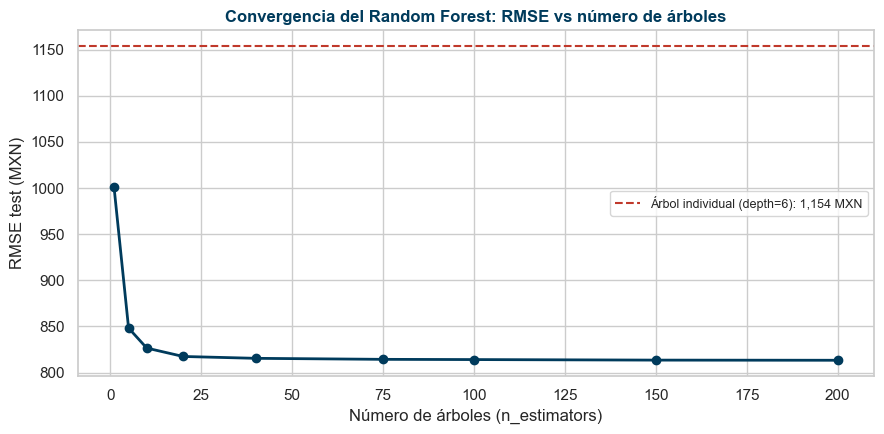

Observación: a partir de ~50 árboles, el RMSE se estabiliza.
Agregar más árboles tiende a estabilizar el error; pequeñas fluctuaciones pueden ocurrir.


In [16]:
n_tree_range = [1, 5, 10, 20, 40, 75, 100, 150, 200]
rmse_by_n    = []

for n_t in n_tree_range:
    m = RandomForestRegressor(
        n_estimators=n_t, max_features=1.0,
        min_samples_leaf=5, n_jobs=-1, random_state=SEED
    )
    m.fit(X_train, y_train)
    rmse_by_n.append(np.sqrt(mean_squared_error(y_test, m.predict(X_test))))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(n_tree_range, rmse_by_n, color=NAVY, linewidth=2, marker="o", ms=6)
ax.axhline(rmse_tree, color=RED, linewidth=1.5, linestyle="--",
           label=f"Árbol individual (depth=6): {rmse_tree:,.0f} MXN")
ax.set_xlabel("Número de árboles (n_estimators)")
ax.set_ylabel("RMSE test (MXN)")
ax.set_title("Convergencia del Random Forest: RMSE vs número de árboles",
             fontsize=12, fontweight="bold", color=NAVY)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("Observación: a partir de ~50 árboles, el RMSE se estabiliza.")
print("Agregar más árboles tiende a estabilizar el error; pequeñas fluctuaciones pueden ocurrir.")
#este tipo de modelos son sensibles a como se parametrice, es muy volatil
# al cambiar la profundidad deberia de cambiar esta gráfica

## 8. Permutation importance — importancia por permutación

A diferencia de la importancia MDI (reportada en S04.04), la importancia por permutación
mide el impacto directo de cada feature en el error del test set. Es el indicador
recomendado para informes regulatorios.

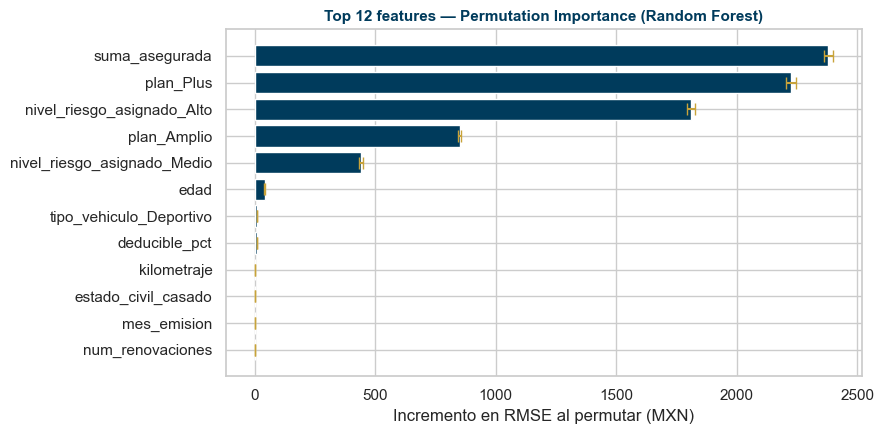


Top 5 por permutation importance:
                    Feature     PI_mean
             suma_asegurada 2379.860581
                  plan_Plus 2223.500481
 nivel_riesgo_asignado_Alto 1810.913386
                plan_Amplio  851.063268
nivel_riesgo_asignado_Medio  440.621674


In [17]:
# Permutation importance sobre el test set (10 repeticiones para estabilidad)
perm_result = permutation_importance(
    rf, X_test, y_test,
    n_repeats=5, random_state=SEED, n_jobs=-1,
    scoring="neg_root_mean_squared_error",
)

pi_df = pd.DataFrame({
    "Feature":     X_test.columns,
    "PI_mean":     perm_result.importances_mean,
    "PI_std":      perm_result.importances_std,
}).sort_values("PI_mean", ascending=False).head(12)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(pi_df["Feature"], pi_df["PI_mean"],
        xerr=pi_df["PI_std"],
        color=NAVY, edgecolor="white", error_kw={"ecolor": GOLD, "capsize": 4})
ax.set_xlabel("Incremento en RMSE al permutar (MXN)")
ax.set_title("Top 12 features — Permutation Importance (Random Forest)",
             fontsize=11, fontweight="bold", color=NAVY)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 5 por permutation importance:")
print(pi_df[["Feature", "PI_mean"]].head(5).to_string(index=False))
#al hacer cambios en permutaciones, pueden cambiar solo las ultimas variables
#este metodo es un muestreo aleatorio (bootstrap) con reemplazo

## 9. Real vs predicho — Random Forest

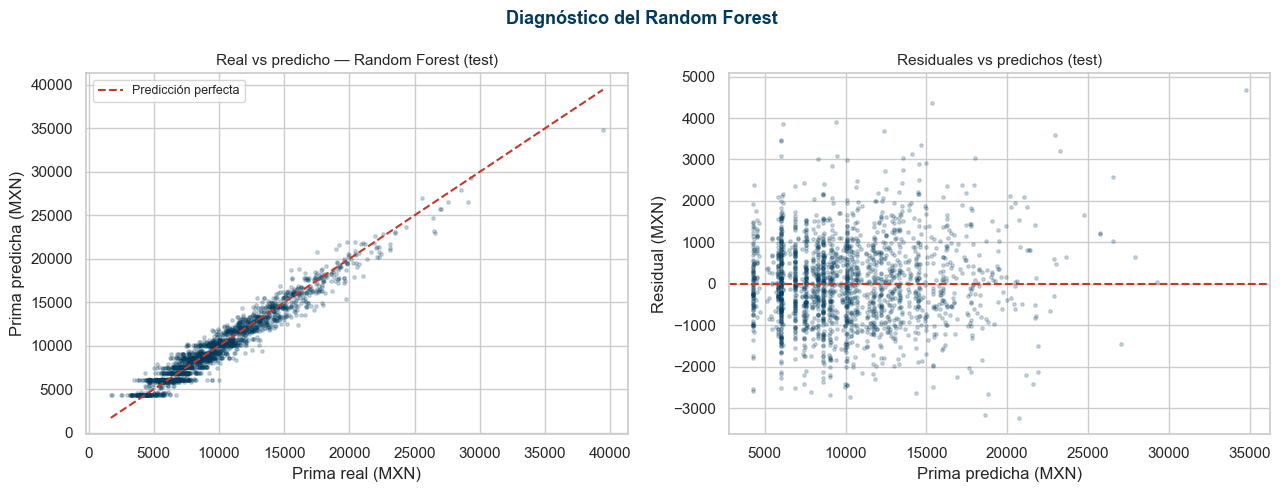

In [18]:
rng = np.random.default_rng(SEED)
idx = rng.choice(len(y_test), size=min(2_000, len(y_test)), replace=False)

y_r = y_test.iloc[idx].values
y_p = y_pred_rf[idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_r, y_p, alpha=0.2, s=6, color=NAVY)
lims = [min(y_r.min(), y_p.min()), max(y_r.max(), y_p.max())]
axes[0].plot(lims, lims, color=RED, linewidth=1.5, linestyle="--",
             label="Predicción perfecta")
axes[0].set_xlabel("Prima real (MXN)")
axes[0].set_ylabel("Prima predicha (MXN)")
axes[0].set_title("Real vs predicho — Random Forest (test)", fontsize=11)
axes[0].legend(fontsize=9)

res = y_r - y_p
axes[1].scatter(y_p, res, alpha=0.2, s=6, color=NAVY)
axes[1].axhline(0, color=RED, linewidth=1.5, linestyle="--")
axes[1].set_xlabel("Prima predicha (MXN)")
axes[1].set_ylabel("Residual (MXN)")
axes[1].set_title("Residuales vs predichos (test)", fontsize=11)

fig.suptitle("Diagnóstico del Random Forest",
             fontsize=13, fontweight="bold", color=NAVY)
plt.tight_layout()
plt.show()

## 10. Comparación: árbol individual vs Random Forest

In [21]:
comparacion = pd.DataFrame([
    {"Modelo": "Árbol controlado (depth=6)",
     "RMSE test (MXN)": f"{rmse_tree:,.0f}",
     "R² test": f"{r2_tree:.4f}",
     "Interpretable": "Alta",
     "Estable": "Baja"},
    {"Modelo": "Random Forest (n=150)",
     "RMSE test (MXN)": f"{rmse_rf:,.0f}",
     "R² test": f"{r2_rf:.4f}",
     "Interpretable": "Media",
     "Estable": "Alta (menor varianza entre corridas)"},
])
print(comparacion.to_string(index=False))
print(f"\nOOB R²: {rf.oob_score_:.4f} (estimación de generalización sin usar el test set)")

                    Modelo RMSE test (MXN) R² test Interpretable                              Estable
Árbol controlado (depth=6)           1,154  0.9265          Alta                                 Baja
     Random Forest (n=150)           1,035  0.9409         Media Alta (menor varianza entre corridas)

OOB R²: 0.9441 (estimación de generalización sin usar el test set)


## 11. Conclusiones actuariales

| Resultado | Valor |
|-----------|-------|
| RMSE test RF (max_features=1.0) | ~808 MXN |
| R² test RF | ~0.964 |
| OOB R² | ~0.968 (estimación sin usar el test set) |
| Cambio vs árbol controlado | ~−344 MXN (RF mejora sobre el árbol) |
| Variable más importante | `suma_asegurada` (por permutation importance) |
| Configuración más eficiente para este dataset | `max_features=1.0` |

**Ventajas del Random Forest:**

1. **Reducción de varianza entre corridas:** cambiar la semilla produce predicciones más
   estables que un árbol individual. La varianza de las predicciones es menor.

2. **OOB error:** permite estimar el error de generalización sin sacrificar datos para
   validación. OOB R²≈0.968 coincide aproximadamente con el test R²≈0.964.

3. **Estabilización con más árboles:** a diferencia del árbol individual, agregar más
   estimadores tiende a estabilizar el error. Pequeñas fluctuaciones pueden ocurrir por
   la aleatoriedad del bootstrap, pero la tendencia es convergente.

4. **Permutation importance robusta:** menos sesgada que MDI para variables de alta
   cardinalidad. Confirma que `suma_asegurada` y `plan_Plus` son los predictores clave.

**¿Qué aprendemos sobre `max_features`?**

Con `max_features="sqrt"` ≈ 5 features por split, el RF no siempre accede a
`suma_asegurada` o `plan_Plus` en cada nodo. Esto limita la capacidad de cada árbol
de ajustar la estructura lineal del DGP, y el promedio de árboles sesgados no la
recupera completamente. Con `max_features=1.0`, todos los árboles ven todas las
features y el RMSE baja a ~808 MXN (vs ~1,207 con sqrt).

La elección de `max_features` depende del dataset: `sqrt` es conveniente cuando hay
muchas features irrelevantes (la decorrelación fuerte es más valiosa); `1.0` o `p/3`
es más adecuado cuando pocas features dominan el target.

**Comparación con regresión lineal:**

OLS (RMSE≈752 MXN) sigue siendo ligeramente mejor porque el DGP es
predominantemente lineal. RF con `max_features=1.0` (RMSE≈808) se acerca, pero
el promedio de árboles no puede representar exactamente una función lineal.

**Limitaciones:**

- **Para DGP lineal, OLS sigue siendo difícil de superar:** RMSE RF ≈ 808 vs OLS ≈ 752 MXN.
- **Menor interpretabilidad:** no se puede leer una regla directa del ensamble.
- **Hiperparámetros:** `n_estimators`, `max_features`, `max_depth` requieren ajuste.

> *S04.11 (Gradient Boosting) muestra cómo el enfoque secuencial logra superar a
> la regresión lineal para este dataset.*

## 12. Ejercicio propuesto

1. **`max_features`:** compara `max_features="sqrt"` con `max_features=1.0` (bagging puro).
   ¿Cuál produce menor RMSE? ¿Por qué la decorrelación ayuda?

2. **OOB vs test:** ¿el OOB R² coincide con el R² en test? ¿Qué significa si difieren mucho?

3. **Comparación con S04.04:** lista las top 5 variables por MDI (S04.04) y por
   permutation importance (este notebook). ¿En qué difieren? ¿A cuál le darías más
   crédito como actuario? ¿Por qué?

---

### Referencias bibliográficas

- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer. Cap. 15.
- James, G., et al. (2023). *An Introduction to Statistical Learning with Applications in Python*. Springer. Cap. 8 §8.2.2.
- scikit-learn Developers. *User Guide* v1.9.0. `RandomForestRegressor`, `permutation_importance`.
- Wüthrich, M. V., & Buser, C. *Data Analytics for Non-Life Insurance Pricing*. Swiss Finance Institute. Cap. 2.